In [ ]:
# python setup.py install
# pip install fasttext openpyxl pyreadstat utils xlrd codauto

In [1]:
import pandas as pd
import os
import sys
import re
import pickle
from codauto import Structured, StructuredWZ
from codauto import Codifier
from codauto import CodifierFastText
#sys.path.append("/home/onyxia/work/WP10_Cluster1_StatCodGen/codauto")
#from structured import Structured, StructuredWZ
#from codifier import Codifier
#from codifier_fasttext import CodifierFastText

# German WZ Classification

In [2]:
root_path = './test'
language = 'de'

## Using Structured for German NACE

In [3]:
# Load the structure downloaded from the link provided earlier
path_struc_wz = r'./../resources'#/WP10_Cluster1_StatCodGen/de/wz_classification/' # Change the path to the location of the downloaded file
name_stuc_wz = 'WZ_2025-DE-2026-01-27-Gliederung.xlsx'
structure_wz_df = pd.read_excel(
    os.path.join(path_struc_wz, name_stuc_wz),
    sheet_name=1,
    dtype=str,
    skiprows=0,
    header=0,
    usecols=[0,2]
)
# For any classification, a DataFrame with two columns must be used: the first with the classification codes and the second with the titles.
# The codes must be provided in hierarchical order, meaning that parent classes must appear before their children.
structure_wz_df.head()

/opt/python/lib/python3.13/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Schlüssel WZ 2025,Titel
0,A,"Land- und Forstwirtschaft, Fischerei"
1,01,"Landwirtschaft, Jagd und damit verbundene Täti..."
2,01.1,Anbau ein- und zweijähriger Pflanzen
3,01.11,Anbau von anderem Getreide als Reis sowie von ...
4,01.11.0,Anbau von anderem Getreide als Reis sowie von ...


In [4]:
# Generate the instance of StructuredWZ
wz_structure = StructuredWZ(
    structure_df=structure_wz_df,
    names_l=[
    'Section',
    'Division',
    'Group',
    'Class',
    'Subclass'
    ] # Names of the levels ordered from highest to lowest hierarchy
# As a best practice, it is recommended to use underscores instead of spaces and to avoid accents
)
wz_structure.level_dict

{0: 'Section', 1: 'Division', 2: 'Group', 3: 'Class', 4: 'Subclass'}

In [ ]:
# Inspect the structure
#wz_structure.get_level('01.1')

In [ ]:
#wzs = wz_structure.load_structue(structure_wz_df)
#wzs[wzs['level'] == 1]

## Using Codifier for German NACE

In [5]:
# WZ test data
train_df = pd.DataFrame({'label': ['35122', '78202', '23200', '71126']*20,
                         'text': ['text1', 'text2', 'word1', 'word2']*20}) 
test_df = pd.DataFrame({'label': ['35122', '78202']*20, 
                        'text': ['tekst3', 'tekstt2']*20, 
                        'source': ['s1', 's1']*20}) 

In [6]:
wz_codifier = CodifierFastText(
    root_path=root_path,
    structure_instance=wz_structure,
    train_df=train_df,
    test_df=test_df,
    language=language
)

2026-02-10 11:22:16,685 - INFO - Loading train_df..
2026-02-10 11:22:16,686 - INFO - train_df raw data count: 80
2026-02-10 11:22:16,691 - INFO - train_df bad codes count: 0
2026-02-10 11:22:16,692 - INFO - train_df bad descriptions count: 0
2026-02-10 11:22:16,694 - INFO - train_df pruned data count: 80
2026-02-10 11:22:16,695 - INFO - train_df has 979 codes unrepresented: {'77399', '91301', '56400', '33150', '85402', '84110', '03300', '25120', '47632', '08930', '86103', '10131', '43321', '82920', '01259', '31009', '23131', '90120', '47301', '46491', '68111', '20599', '28150', '86941', '43210', '46450', '25220', '73300', '23140', '10920', '23650', '46133', '95313', '52320', '88104', '92004', '59203', '91220', '93291', '46822', '23430', '47781', '72101', '92003', '01301', '96992', '38330', '25510', '38322', '47210', '64192', '97000', '26111', '85311', '30920', '74130', '92001', '46154', '46220', '25634', '01191', '84220', '24100', '10840', '52100', '22230', '35150', '28970', '28112', '

In [7]:
wz_codifier.train()

Read 0M words
Number of words:  5
Number of labels: 4
2026-02-10 11:22:20,645 - INFO - Train time: 0h 0m 0s
Progress: 100.0% words/sec/thread:    8008 lr:  0.000000 avg.loss:  0.999700 ETA:   0h 0m 0s


In [8]:
# Example prediction
desc_l=[
    'Frisör',
    'Haarschneider'
       ]

mode = 'assistance'
hierarchical_level = 5
threshold = 0.03

wz_codifier.predict(
    desc_l=desc_l,
    mode=mode,
    hierarchical_level=hierarchical_level,
    threshold=threshold
)

[{'description': 'Frisör',
  'original_code': None,
  'label': ('71126', '78202', '35122', '23200'),
  'confidence': (26, 25, 25, 24),
  'hierarchical_level': 5,
  'identifier': 0,
  'title': ('Sonstige Ingenieurbüros',
   'Sonstige Überlassung von Arbeitskräften',
   'Elektrizitätserzeugung aus erneuerbaren Energieträgern zur Verteilung',
   'Herstellung von feuerfesten keramischen Werkstoffen und Waren')},
 {'description': 'Haarschneider',
  'original_code': None,
  'label': ('71126', '78202', '35122', '23200'),
  'confidence': (26, 26, 24, 24),
  'hierarchical_level': 5,
  'identifier': 1,
  'title': ('Sonstige Ingenieurbüros',
   'Sonstige Überlassung von Arbeitskräften',
   'Elektrizitätserzeugung aus erneuerbaren Energieträgern zur Verteilung',
   'Herstellung von feuerfesten keramischen Werkstoffen und Waren')}]

2026-02-10 11:23:07,903 - INFO - Test set size 40 for source all
2026-02-10 11:23:07,905 - INFO - test_set_all has 981 codes unrepresented
Predicting test_set for 15 classes: 100%|██████████| 40/40 [00:00<00:00, 126.48it/s]
/opt/python/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/python/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/python/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/python/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/python/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _me

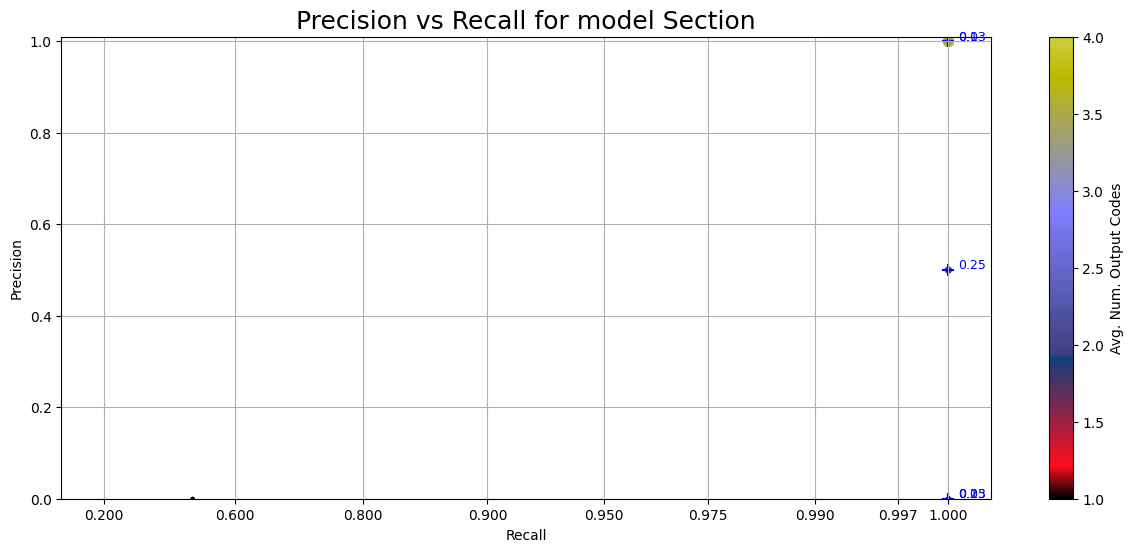

2026-02-10 11:23:16,429 - INFO - Threshold 0.8 not found for level Division in precision_vs_recall_multi_conf_15.
2026-02-10 11:23:16,437 - INFO - Threshold 0.8 not found for level Division in precision_vs_recall_multi_conf_1.


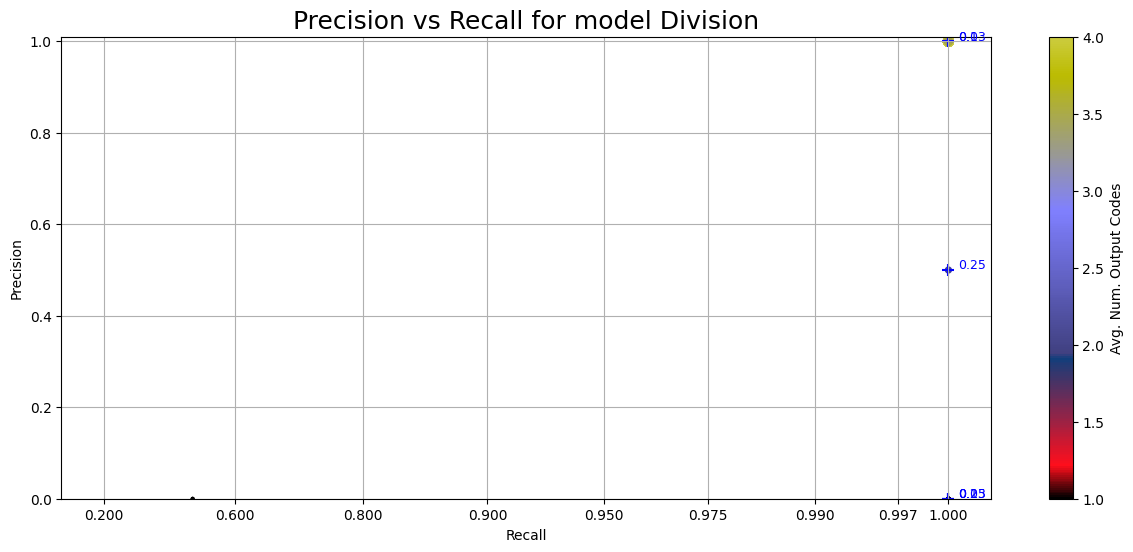

2026-02-10 11:23:16,645 - INFO - Threshold 0.8 not found for level Group in precision_vs_recall_multi_conf_15.
2026-02-10 11:23:16,653 - INFO - Threshold 0.8 not found for level Group in precision_vs_recall_multi_conf_1.


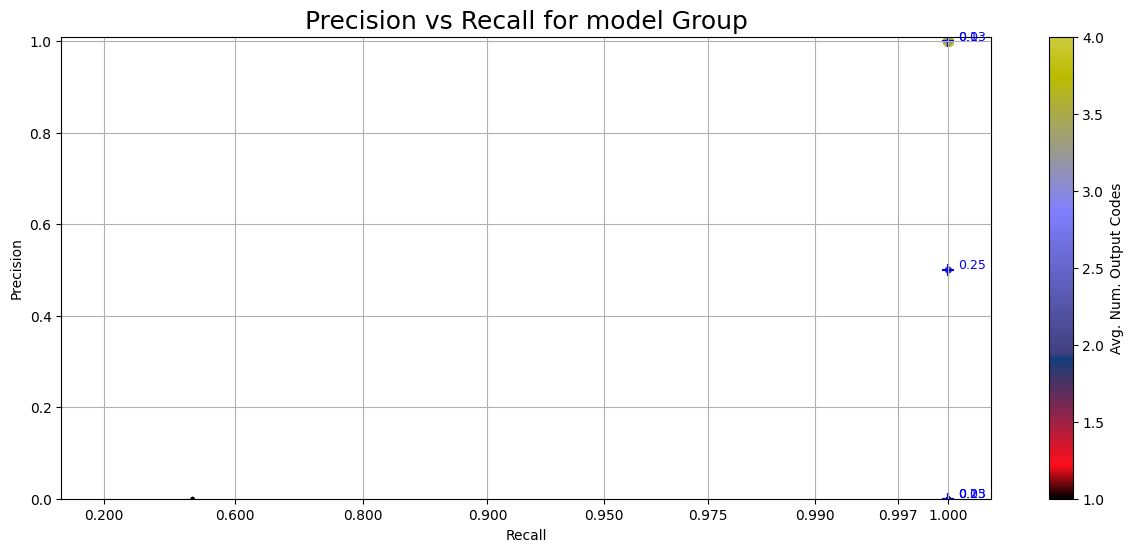

2026-02-10 11:23:16,855 - INFO - Threshold 0.8 not found for level Class in precision_vs_recall_multi_conf_15.
2026-02-10 11:23:16,862 - INFO - Threshold 0.8 not found for level Class in precision_vs_recall_multi_conf_1.


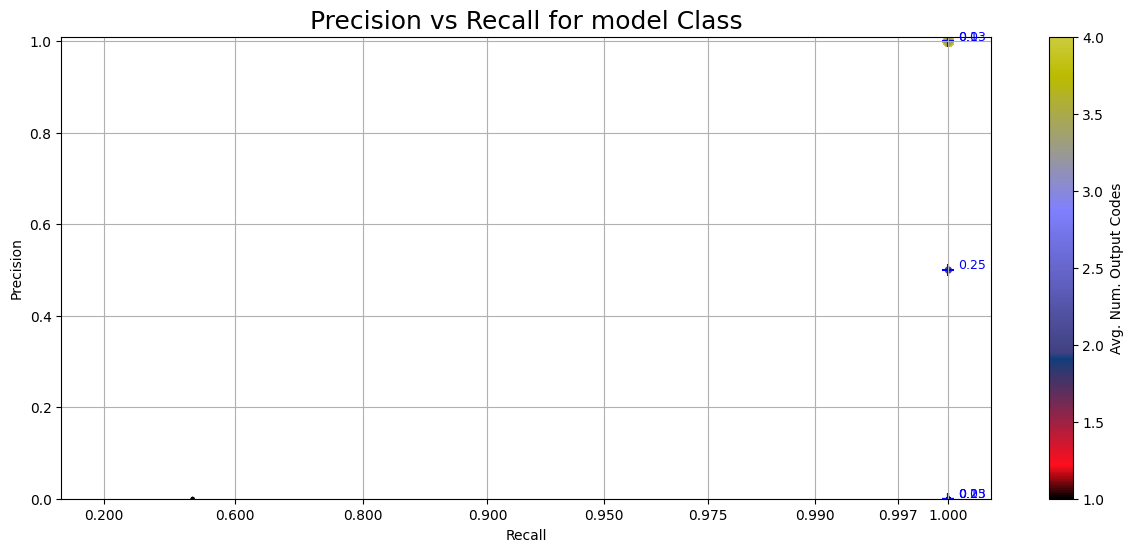

2026-02-10 11:23:17,065 - INFO - Threshold 0.8 not found for level Subclass in precision_vs_recall_multi_conf_15.
2026-02-10 11:23:17,073 - INFO - Threshold 0.8 not found for level Subclass in precision_vs_recall_multi_conf_1.


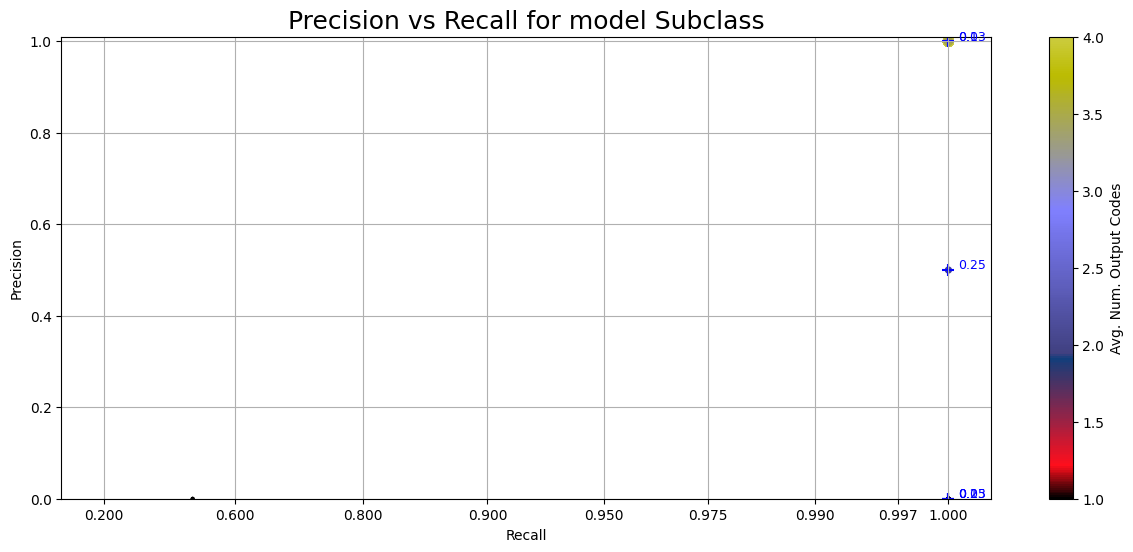

{'Section': {'accuracy': 0.0,
  'f1_score': {'micro': 0.0, 'macro': 0.0, 'weighted': 0.0}},
 'Division': {'accuracy': 0.0,
  'f1_score': {'micro': 0.0, 'macro': 0.0, 'weighted': 0.0}},
 'Group': {'accuracy': 0.0,
  'f1_score': {'micro': 0.0, 'macro': 0.0, 'weighted': 0.0}},
 'Class': {'accuracy': 0.0,
  'f1_score': {'micro': 0.0, 'macro': 0.0, 'weighted': 0.0}},
 'Subclass': {'accuracy': 0.0,
  'f1_score': {'micro': 0.0, 'macro': 0.0, 'weighted': 0.0}}}

In [9]:
wz_codifier.evaluate()